# Neural networks


Language models which use frequency based approaches as shown in the last chapter come along with potential pitfalls. For instance, the bag-of-words approach produces sparse high-dimensional vectors which has no further information about the context of the original text. Dictionary based approaches depend on the dictionary used and also lose contextual information. In the remainder of this course, we are going to learn about language models that aim to tackle these issues. The models we are going to use usually create numerical representations of words and documents that capture semantic meaning. This means numerical representations are similar if the meaning of words and documents is similar and vice versa. To learn about the meaning of words and documents parametric statistical models are used. These models need to be trained on corpora. The architecture of these models is developed using neural networks. This is why we first discuss neural networks in general in this chapter. Please also note that not all language models use neural networks, however, all models used from now on. Other modeling approaches rely upon matrix decompositions of document term matrices or probablitic modeling of text generation. 

## The building blocks of neural networks

Each neural network has so called layers. The first layer which receives input data is called the input layer, the last layer in a neural network returns processed input and is called the output layer. In between those two layers hidden layers can be used. Each layer consists of a number of neurons which is defined by the user. Furthermore, the output of each layer is activated by activation functions. Let us summarize, each neural network has:

* layers
* neurons
* activation functions

Besides these similarities a large amount of different neural network architectures exists. Let us define the neurons $\boldsymbol{h}^{(l)}$ of a layer $l$ by: 

$$
\boldsymbol{h}^{(l)} = 
\begin{pmatrix}
    h_1^{(l)} \\
    \vdots \\
    h_{p_l}^{(l)}
\end{pmatrix}
$$

$p_l$ represents the number of neurons in layer $l$. The neurons of each layer (except for the output layer) are aggregated in a weighted fashion which is called affine map:

$$
z^{(l)} = w_{1}^{(l-1)} h_1^{(l-1)} + w_{2}^{(l-1)} h_2^{(l-1)} + ... + w_{p_{l-1}}^{(l-1)} h_{p_{l-1}}^{(l-1)} + b^{(l-1)}
$$

The output of this transformation is used as input for an activation function $g$. Various activation functions are used for neural networks. Popular examples are 

| Name | Function  |
|- | - |
| Identity | $g(z) = z$ |
| Relu | $g(z) = \max (z, 0)$ |
| Sigmoid | $g(z) = \frac{1}{1 + e^{-z}} $ |

See the output below for their visualization.

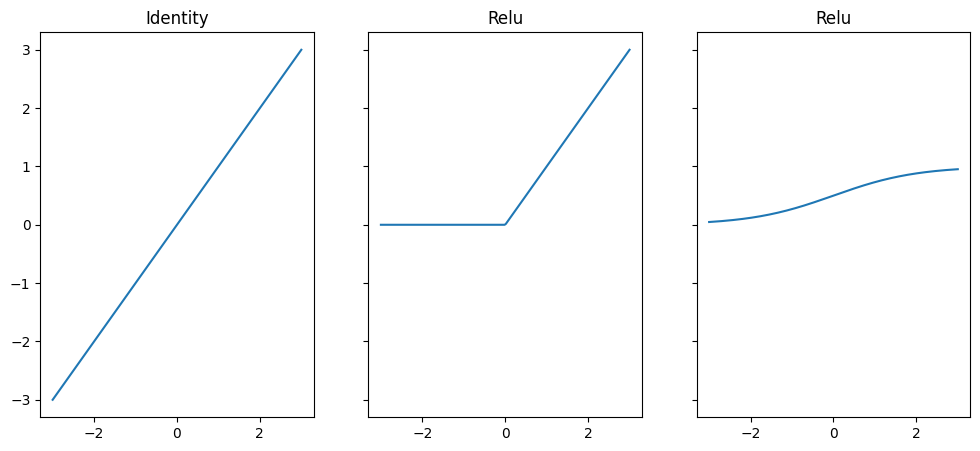

In [13]:
import numpy as np
import matplotlib.pylab as plt


z = np.linspace(-3, 3, 200)

fig, axs = plt.subplots(1, 3, figsize = (12, 5), sharex=True, sharey=True)
axs[0].plot(z, z)
axs[0].set_title("Identity")
axs[1].plot(z, np.maximum(z, 0))
axs[1].set_title("Relu")
axs[2].plot(z, (1 + np.exp(-z))**(-1))
axs[2].set_title("Relu")
plt.show()

The result of the activation function is the hidden neuron for the next layer. Thus, to create a single neuron for the next layer, we use:


$$
h^{(l)} = g(z^{(l)}) = g \left(w_{1}^{(l-1)} h_1^{(l-1)} + w_{2}^{(l-1)} h_2^{(l-1)} + ... + w_{p_{l-1}}^{(l-1)} h_{p_{l-1}}^{(l-1)} + b^{(l-1)}\right)
$$

If you use different values for the parameters $w_{1}^{(l-1)}, w_{2}^{(l-1)}, ..., w_{p_{l-1}}^{(l-1)}, b^{(l-1)}$, we generate different neurons. And this is what usually is done, especially for hidden layers. The user sets a desired number of hidden neurons $p_l$ which are calculated by:

$$
\boldsymbol{h}^{(l)} = g \left( \boldsymbol{W}^{(l-1), T} \boldsymbol{h}^{(l-1)} + \boldsymbol{b}^{(l-1)}  \right) 
$$

with 

$$
\boldsymbol{W}^{(l-1)} = 
\begin{pmatrix}
w_{11}^{(l-1)} & \cdots & w_{1p_{l-1}}^{(l)} \\
\vdots & \ddots \\
w_{p_{l-1}1}^{(l-1)} & \cdots & w_{p_{l-1}p_{l}}^{(l-1)} \\
\end{pmatrix},
\boldsymbol{b}^{(l)} = 
\begin{pmatrix}
b_1^{(l-1)} \\
\vdots \\
b_{p_{l}}^{(l-1)} \\
\end{pmatrix}
$$

Technically, activation functions can be different for every layer such that we may also want to write $g^{(l-1)}$ instead of $g$.

$$
\boldsymbol{h}^{(l)} = g^{(l)} \left( \boldsymbol{W}^{(l-1), T} \boldsymbol{h}^{(l-1)} + \boldsymbol{b}^{(l-1)}  \right) 
$$

These operations are repeated for as many layers as desired by the user. For instance, let us take a look how data would be processed for a neural network with one hidden layer, two hidden neurons and one neuron in the output layer. Let us further assume that the network receives realizations of three input variables $x_1, x_2, x_3$ in the input layer and only the identity function is used for activation in each layer.

The input neurons are $h_1^{(1)} = x_1, h_2^{(1)} = x_2, h_3^{(1)} = x_3$. The hidden neurons for the next layer are calculated by:

$$
\boldsymbol{h}^{(2)} = g^{(1)} \left(
\begin{pmatrix}
w_{11}^{(1)} & w_{21}^{(1)} & w_{31}^{(1)} \\
w_{12}^{(1)} & w_{22}^{(1)} & w_{32}^{(1)} \\
\end{pmatrix} 
\begin{pmatrix}
h_1^{(1)} \\ h_2^{(1)} \\ h_3^{(1)} \\
\end{pmatrix} +
\begin{pmatrix}
b_{1}^{(1)}  \\
b_{2}^{(1)}  \\
\end{pmatrix} 
\right) = 
\begin{pmatrix}
w_{11}^{(1)} & w_{21}^{(1)} & w_{31}^{(1)} \\
w_{12}^{(1)} & w_{22}^{(1)} & w_{32}^{(1)} \\
\end{pmatrix} 
\begin{pmatrix}
h_1^{(1)} \\ h_2^{(1)} \\ h_3^{(1)} \\
\end{pmatrix} +
\begin{pmatrix}
b_{1}^{(1)}  \\
b_{2}^{(1)}  \\
\end{pmatrix} =
\begin{pmatrix}
h_{1}^{(2)}  \\
h_{2}^{(2)}  \\
\end{pmatrix}
$$

To produce the output of the neural network, we further process these neurons through the second (output) layer by:
 
$$
h^{(3)} = g^{(2)} \left(
\begin{pmatrix}
w_{1}^{(2)} & w_{2}^{(2)}  \\
\end{pmatrix} 
\begin{pmatrix}
h_1^{(2)} \\ h_2^{(2)} \\
\end{pmatrix} +
b^{(2)}
\right) = 
w_{1}^{(2)} h_1^{(2)} + w_{2}^{(2)} h_2^{(2)} + b^{(2)}
$$

The only thing which is fixed here are the input values $h_1^{(1)} = x_1, h_2^{(1)} = x_2, h_3^{(1)} = x_3$. All other values $\boldsymbol{W}^{(1)}, \boldsymbol{b}^{(1)}, \boldsymbol{W}^{(2)}, \boldsymbol{b}^{(2)}$ are parameters which need to be trained for the model. The number of parameters is determined by the number of hidden neurons which we set for every layer. The more hidden neurons we would like to use, the higher the number of parameters which needs to be trained. What we see in the example above is what is called a forward pass which describes how the input data is processed through the network. Note that there are no real limits regarding the architecture. For instance you can also define a neural network which produces more than one neuron in the output layer. However, the question that remains is how are the parameters trained?

In order to train the parameters we need another function which is called loss or cost function and supposed to be minimized by adjusting parameters accordingly. The choice of the loss function depends on the task which is supposed to be tackled with the neural network. Popular examples for such tasks belong to the field of supervised learning where and are regression or classification problems. Let us take a look at these examples to dig deeper into the training process of a neural network.

### Regression task

A regression model is supposed to make predictions for a numerical values, usually a real valued number. Given information by feature variables (which are also called independent or predictor variables), the model processes this information to make predictions for the target variable (also called dependent variable). Generally, this can be written by $f_{\boldsymbol{\Theta}}\left(\boldsymbol{x}\right)$, where $f$ is the function which processes feature variables $\boldsymbol{x}$. Usually the model predictions depend on parameters which are collected in the set $\boldsymbol{\Theta}$. An easy example is the linear regression model. The parameters are $\boldsymbol{\Theta}= \lbrace w_1, ..., w_p, b \rbrace$, and, the function is defined by:

$$
f_{\boldsymbol{\Theta}}\left(\boldsymbol{x}\right) = w_1 x_1 + ... + w_p x_p + b = \boldsymbol{w}^T \boldsymbol{x} + b = \hat{y}_{i, \boldsymbol{\Theta}}
$$

If we want to tackle a regression task with a neural network, the output activation is supposed to be the identity function to create a real valued number. Besides, all components of the neural network can be set by the user as desired. To train the parameters of a neural network (or other models for regression tasks), we can choose among different loss functions, however, the most common is the (average) sum of squared deviations.

$$
L \left(\boldsymbol{y}, \boldsymbol{\hat{y}}_{\boldsymbol{\Theta}}\right) = \sum_i \left(y_i - \hat{y}_{i, \boldsymbol{\Theta}} \right)^2 
$$

with $\hat{y}_{i, \boldsymbol{\Theta}} =  f_{\boldsymbol{\Theta}}\left(\boldsymbol{x}_i\right) $ being the prediction for $y_i$. Thus, the loss function value for a neural network is smaller if model predictions are close to realizations on average. In essence, we face an optimization problem to train all model parameters which is:

$$
\min_{\boldsymbol{\Theta}} L \left(\boldsymbol{y}, \boldsymbol{\hat{y}}_{\boldsymbol{\Theta}}\right)
$$

and, given data, we can use the solution to this optimization:

$$
\hat{\boldsymbol{\Theta}} = \argmin_{\boldsymbol{\Theta}} L \left(\boldsymbol{y}, \boldsymbol{\hat{y}}_{\boldsymbol{\Theta}}\right)
$$

While such a solution is available in closed form for the multiple linear regression model it is not for neural networks, nor is it unique. This is why we usually aim to approximate this solution by numerical optimization techniques. With respect to neural networks, gradient descent techniques are very popular. We are going to take a look at this later, but, first let us take a look at classification tasks to examine some similarities regarding the architecture and training of neural networks.

### Classification tasks

In case of classification tasks, the model is supposed to predict categories of a target variable. If only two categories exist, this is called binary classification, for more than two categories, we speak about multi-class classification. Usually the categories are disjoint, meaning, only one of the categories can occur at a time. If more categories can occur for one observation, it is called multi-label classification.

Usually, categories are encoded into numbers or by one-hot-vector encoding. While the original observation is a unique label, e.g., "buy", the numerical representation is $y = 1$, and after one-hot encoding it is $\begin{pmatrix} 0 & 1 \end{pmatrix}$. In general, one-hot-vectors are vectors with dimensionality being equal to the number of categories and a $1$ at the position which represents the corresponding category. For instance, if the original target variable has the categories "buy", "not buy", we can first encode it in numbers like $0, 1$ or $1, 2$ or to one-hot-vectors $\begin{pmatrix} 0 & 1 \end{pmatrix}$, $\begin{pmatrix} 1 & 0 \end{pmatrix}$. For binary classification, one usually uses a numerical dummy encoding $0, 1$ with $1$ representing the category of interest. One-hot-vectors are mostly used for classification with more than two categories. For all classification models, we usually predict the probability for being a specific category instead of a direct category prediction. With respect to neural networks, this determines the choice of the output activation function. 

Given a binary classification task, one uses the sigmoid function in the output layer. This function takes a real-valued number $z$ and maps it to the numerical range $\left(0, 1\right)$. The easiest version of this model is represented by the logistic regression model, which can be considered as a special form for a neural network without hidden layer and the sigmoid activation. This is basically the linear regression model whose output is inserted in the sigmoid function:

$$
f_{\boldsymbol{\Theta}}\left(\boldsymbol{x}\right) = \frac{1}{1 + e^{- \left(w_1 x_1 + ... + w_p x_p + b\right)}} = \frac{1}{1 + e^{-  \left( \boldsymbol{w}^T \boldsymbol{x} + b \right) }} = \hat{y}_{i, \boldsymbol{\Theta}}
$$

Here, $\hat{y}_{i, \boldsymbol{\Theta}}$ represents the probability for observation $i$ to fall into category $1$. Note that a neural network is the same with arbitrary hidden layers between the input and the output layer. To train the parameters for a binary classification model, we need a loss function which is lower if probability predictions are in line with actual categorical observations. This means if $y=0$ the model is supposed to predict a small value for $\hat{y}_{i, \boldsymbol{\Theta}}$ and if $y=1$, $\hat{y}_{i, \boldsymbol{\Theta}}$ should be a high value close towards $1$. We should mention that a low value for $\hat{y}_{i, \boldsymbol{\Theta}}$ is a high probability prediction for $y=0$ as $P\left(y = 0\right) = 1 - \hat{y}_{i, \boldsymbol{\Theta}}$. A popular loss function is the cross-entropy. The model is considered to provide better predictions the lower:

$$
L \left(\boldsymbol{y}, \boldsymbol{\hat{y}}_{\boldsymbol{\Theta}}\right) = - \sum_i y_i \log \left(\hat{y}_{i, \boldsymbol{\Theta}}\right) + \left(1 - y_i\right) \log \left(1 - \hat{y}_{i, \boldsymbol{\Theta}}\right)
$$

For a better understanding of the intuition of this loss function, take a look in output below. We plot the value of $-\log(p)$ for $p \in (0, 1)$. As $-\log(p)$ is strictly monotonic decreasing, smaller loss values result for observations with high probability predictions for the realized category.

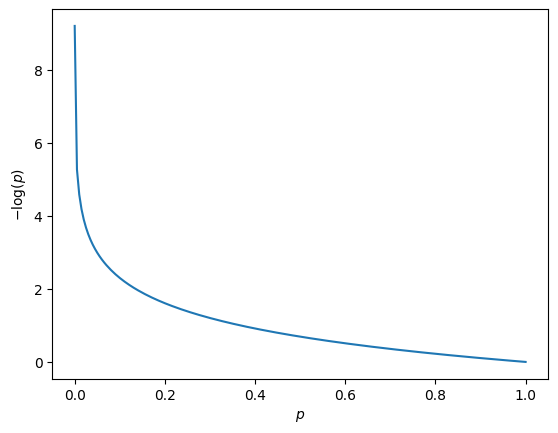

In [6]:
import numpy as np
import matplotlib.pylab as plt


p = np.linspace(0.0001, 0.9999, 200)
plt.plot(p, -np.log(p))
plt.xlabel(r"$p$")
plt.ylabel(r"$-\log(p)$")
plt.show()

While the loss function is quite similar for multi-class classification...